# 02 — Baseline Training
**Project:** ViT Reliability & Explainability Under Medical Distribution Shift
**Author:** Sosna Worku

**Goal:** Fine-tune ViT-B/16 and ResNet50 on NIH ChestX-ray14. Log AUC and loss per epoch.

---
Run all cells top to bottom every new Colab session.

## 0. Setup — Run every session

In [40]:
import os, sys

REPO_PATH = '/content/vit-medical-shift'
GITHUB    = 'https://github.com/sossyh/vit-medical-shift.git'

if os.path.exists(REPO_PATH):
    os.system(f'git -C {REPO_PATH} pull origin main')
else:
    os.system(f'git clone {GITHUB} {REPO_PATH}')

sys.path.insert(0, REPO_PATH)
print('Repo ready!')

Repo ready!


In [41]:
from google.colab import drive
drive.mount('/content/drive')
print('Drive mounted!')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted!


In [42]:
!pip install -q timm torchmetrics grad-cam einops pyyaml
print('Packages ready!')

Packages ready!


In [43]:
import torch
print('GPU:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU only')

GPU: Tesla T4


## 1. Copy Images to Local Disk (faster, no Drive disconnects)

In [44]:
import os
from google.colab import drive

# Force remount
drive.mount('/content/drive', force_remount=True)

# Use rsync — handles large folders much better than cp or shutil
LOCAL_IMG_DIR = '/content/images'
DRIVE_IMG_DIR = '/content/drive/MyDrive/data/nih/images'

os.makedirs(LOCAL_IMG_DIR, exist_ok=True)

print('Copying with rsync (handles large folders better)...')
os.system(f'rsync -a --progress {DRIVE_IMG_DIR}/ {LOCAL_IMG_DIR}/')

n = len(os.listdir(LOCAL_IMG_DIR))
print(f'Done! {n:,} images on local disk')

IMG_DIR   = LOCAL_IMG_DIR
CSV_PATH  = '/content/drive/MyDrive/data/nih/Data_Entry_2017.csv'
CKPT_DIR  = '/content/drive/MyDrive/checkpoints'
os.makedirs(CKPT_DIR, exist_ok=True)
print('IMG_DIR:', IMG_DIR)

Mounted at /content/drive
Copying with rsync (handles large folders better)...
Done! 46,258 images on local disk
IMG_DIR: /content/images


In [45]:
import os

IMG_DIR = '/content/drive/MyDrive/data/nih/images'

# Use shell command to avoid OSError
result = os.popen(f'ls {IMG_DIR} | wc -l').read().strip()
print('Image count:', result)

# Show first few
result2 = os.popen(f'ls {IMG_DIR} | head -5').read().strip()
print('First few:', result2)

Image count: 94875
First few: 00000001_000.png
00000001_001.png
00000001_002.png
00000002_000.png
00000003_000.png


## 2. Config & Device

In [46]:
from src.utils import get_device, set_seed

set_seed(42)
device = get_device()
print('Device:', device)

Using GPU: Tesla T4
Device: cuda


## 3. Load Data

In [47]:
from src.dataset import get_nih_loaders

# subset=0.2 → ~19k images, good for 5-epoch training
# subset=1.0 → full 94k images
SUBSET = 0.2

train_loader, val_loader = get_nih_loaders(
    csv_path    = CSV_PATH,
    img_dir     = IMG_DIR,
    batch_size  = 32,
    subset      = SUBSET,
    num_workers = 0
)

print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')
print(f'Train images  : {len(train_loader.dataset):,}')
print(f'Val images    : {len(val_loader.dataset):,}')

Filtering to available images...
Available: 94,875 / 112,120
Filtering to available images...
Available: 94,875 / 112,120
Filtering to available images...
Available: 94,875 / 112,120
Train batches : 475
Val batches   : 119
Train images  : 15,180
Val images    : 3,795


## 4. Train ViT-B/16

In [49]:
from src.model import get_vit, count_parameters
from src.train import train

print('Loading ViT-B/16...')
vit_model = get_vit(num_classes=14, pretrained=True).to(device)
print(f'Parameters: {count_parameters(vit_model):,}')

vit_config = {
    'training': {
        'epochs'         : 10,
        'lr'             : 1e-4,
        'weight_decay'   : 1e-4,
        'warmup_epochs'  : 1,
        'checkpoint_dir' : f'{CKPT_DIR}/vit_nih/'
    }
}

print('Training ViT-B/16 for 10 epochs (~20 mins)...')
vit_history = train(vit_model, train_loader, val_loader, vit_config, device)

Loading ViT-B/16...
Parameters: 85,809,422
Training ViT-B/16 for 10 epochs (~20 mins)...


Epoch 01 | train=0.1872 | val=0.1705
  ✓ Saved best model → /content/drive/MyDrive/checkpoints/vit_nih/best.pth


Epoch 02 | train=0.1662 | val=0.1663
  ✓ Saved best model → /content/drive/MyDrive/checkpoints/vit_nih/best.pth


Epoch 03 | train=0.1609 | val=0.1625
  ✓ Saved best model → /content/drive/MyDrive/checkpoints/vit_nih/best.pth


Epoch 04 | train=0.1562 | val=0.1624
  ✓ Saved best model → /content/drive/MyDrive/checkpoints/vit_nih/best.pth


...

Epoch 06 | train=0.1465 | val=0.1564
  ✓ Saved best model → /content/drive/MyDrive/checkpoints/vit_nih/best.pth


Epoch 07 | train=0.1389 | val=0.1583


Epoch 08 | train=0.1263 | val=0.1684


Epoch 09 | train=0.1102 | val=0.1786


Epoch 10 | train=0.0979 | val=0.1873


## 5. Evaluate ViT

In [50]:
import torch
import torch.nn as nn
from src.evaluate import compute_auc, compute_ece, print_metrics
from src.train import validate

criterion = nn.BCEWithLogitsLoss()

# Load best checkpoint
best_path = f'{CKPT_DIR}/vit_nih/best.pth'
vit_model.load_state_dict(torch.load(best_path, map_location=device))
print('Loaded best ViT checkpoint!')

val_loss, val_logits, val_labels = validate(vit_model, val_loader, criterion, device)
vit_auc = compute_auc(val_logits, val_labels)
vit_ece = compute_ece(val_logits, val_labels)
print_metrics(vit_auc, vit_ece, split_name='ViT Val')

Loaded best ViT checkpoint!



[ViT Val] Mean AUC : 0.8006
[ViT Val] ECE      : 0.0059

Per-class AUC:
  Atelectasis            0.7764
  Cardiomegaly           0.8692
  Effusion               0.8546
  Infiltration           0.7116
  Mass                   0.7871
  Nodule                 0.7124
  Pneumonia              0.7447
  Pneumothorax           0.8466
  Consolidation          0.8032
  Edema                  0.8854
  Emphysema              0.9100
  Fibrosis               0.7987
  Pleural_Thickening     0.7334
  Hernia                 0.7749


## 6. Train ResNet50 Baseline

In [51]:
from src.model import get_resnet

print('Loading ResNet50...')
resnet_model = get_resnet(num_classes=14, pretrained=True).to(device)
print(f'Parameters: {count_parameters(resnet_model):,}')

resnet_config = {
    'training': {
        'epochs'         : 10,
        'lr'             : 1e-4,
        'weight_decay'   : 1e-4,
        'warmup_epochs'  : 1,
        'checkpoint_dir' : f'{CKPT_DIR}/resnet_nih/'
    }
}

print('Training ResNet50 for 10 epochs (~20 mins)...')
resnet_history = train(resnet_model, train_loader, val_loader, resnet_config, device)

Loading ResNet50...


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

Parameters: 23,536,718
Training ResNet50 for 10 epochs (~20 mins)...


Epoch 01 | train=0.3959 | val=0.1808
  ✓ Saved best model → /content/drive/MyDrive/checkpoints/resnet_nih/best.pth


Epoch 02 | train=0.1739 | val=0.1737
  ✓ Saved best model → /content/drive/MyDrive/checkpoints/resnet_nih/best.pth


...

Epoch 06 | train=0.1613 | val=0.1651
  ✓ Saved best model → /content/drive/MyDrive/checkpoints/resnet_nih/best.pth


Epoch 07 | train=0.1603 | val=0.1646
  ✓ Saved best model → /content/drive/MyDrive/checkpoints/resnet_nih/best.pth


Epoch 08 | train=0.1591 | val=0.1643
  ✓ Saved best model → /content/drive/MyDrive/checkpoints/resnet_nih/best.pth


Epoch 09 | train=0.1585 | val=0.1641
  ✓ Saved best model → /content/drive/MyDrive/checkpoints/resnet_nih/best.pth


Epoch 10 | train=0.1583 | val=0.1640
  ✓ Saved best model → /content/drive/MyDrive/checkpoints/resnet_nih/best.pth


## 7. Evaluate ResNet50

In [52]:
best_path = f'{CKPT_DIR}/resnet_nih/best.pth'
resnet_model.load_state_dict(torch.load(best_path, map_location=device))
print('Loaded best ResNet checkpoint!')

val_loss, val_logits, val_labels = validate(resnet_model, val_loader, criterion, device)
resnet_auc = compute_auc(val_logits, val_labels)
resnet_ece = compute_ece(val_logits, val_labels)
print_metrics(resnet_auc, resnet_ece, split_name='ResNet Val')

Loaded best ResNet checkpoint!



[ResNet Val] Mean AUC : 0.7455
[ResNet Val] ECE      : 0.0027

Per-class AUC:
  Atelectasis            0.7530
  Cardiomegaly           0.7275
  Effusion               0.8342
  Infiltration           0.6989
  Mass                   0.7215
  Nodule                 0.6769
  Pneumonia              0.6879
  Pneumothorax           0.7726
  Consolidation          0.8074
  Edema                  0.8691
  Emphysema              0.8340
  Fibrosis               0.7196
  Pleural_Thickening     0.6881
  Hernia                 0.6458


## 8. Compare ViT vs ResNet

             Label  ViT AUC  ResNet AUC  ViT - ResNet
       Atelectasis 0.776423    0.752955      0.023467
      Cardiomegaly 0.869244    0.727530      0.141714
          Effusion 0.854593    0.834226      0.020367
      Infiltration 0.711618    0.698936      0.012682
              Mass 0.787120    0.721490      0.065630
            Nodule 0.712365    0.676930      0.035434
         Pneumonia 0.744680    0.687912      0.056768
      Pneumothorax 0.846554    0.772591      0.073962
     Consolidation 0.803201    0.807424     -0.004224
             Edema 0.885404    0.869054      0.016349
         Emphysema 0.910000    0.833967      0.076033
          Fibrosis 0.798701    0.719599      0.079103
Pleural_Thickening 0.733423    0.688051      0.045372
            Hernia 0.774875    0.645817      0.129058
              Mean 0.800586    0.745463      0.055123


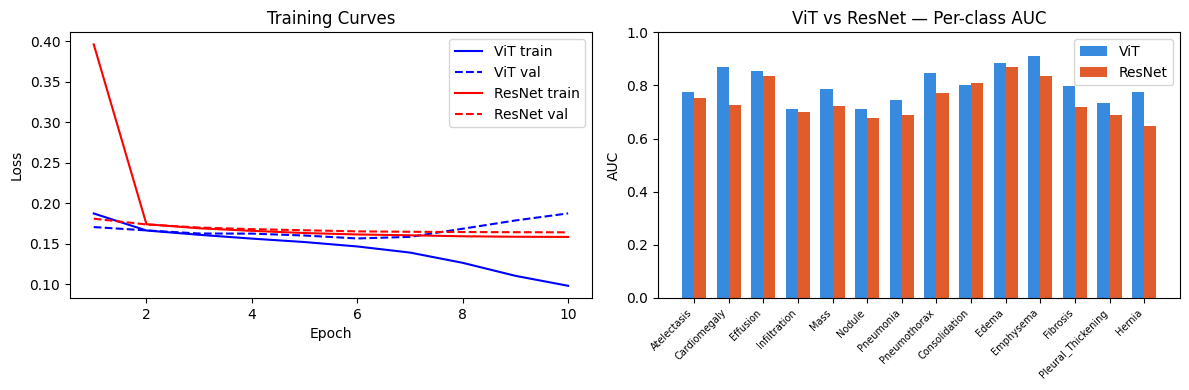

Saved!


In [54]:
import pandas as pd
import matplotlib.pyplot as plt
from src.utils import NIH_LABELS

# Summary table
comparison = pd.DataFrame({
    'Label'       : NIH_LABELS + ['Mean'],
    'ViT AUC'     : [vit_auc[l]    for l in NIH_LABELS] + [vit_auc['mean']],
    'ResNet AUC'  : [resnet_auc[l] for l in NIH_LABELS] + [resnet_auc['mean']],
})
comparison['ViT - ResNet'] = comparison['ViT AUC'] - comparison['ResNet AUC']
print(comparison.to_string(index=False))

# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

epochs = range(1, 11)
axes[0].plot(epochs, [h['train_loss'] for h in vit_history],    'b-',  label='ViT train')
axes[0].plot(epochs, [h['val_loss']   for h in vit_history],    'b--', label='ViT val')
axes[0].plot(epochs, [h['train_loss'] for h in resnet_history], 'r-',  label='ResNet train')
axes[0].plot(epochs, [h['val_loss']   for h in resnet_history], 'r--', label='ResNet val')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Curves')
axes[0].legend()

x = range(len(NIH_LABELS))
w = 0.35
axes[1].bar([i-w/2 for i in x], [vit_auc[l]    for l in NIH_LABELS], w, label='ViT',    color='#378ADD')
axes[1].bar([i+w/2 for i in x], [resnet_auc[l] for l in NIH_LABELS], w, label='ResNet', color='#E05C2A')
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(NIH_LABELS, rotation=45, ha='right', fontsize=7)
axes[1].set_ylabel('AUC')
axes[1].set_title('ViT vs ResNet — Per-class AUC')
axes[1].legend()
axes[1].set_ylim(0, 1)

plt.tight_layout()
os.makedirs(f'{REPO_PATH}/results/figures', exist_ok=True)
plt.savefig(f'{REPO_PATH}/results/figures/baseline_comparison.png', dpi=150)
plt.show()
print('Saved!')

## 9. Save Metrics & Push to GitHub

In [55]:
import json, os
from google.colab import files

os.makedirs(f'{REPO_PATH}/results/metrics', exist_ok=True)

# Save metrics JSON
metrics = {
    'vit'   : {'auc': vit_auc,    'ece': vit_ece},
    'resnet': {'auc': resnet_auc, 'ece': resnet_ece}
}
with open(f'{REPO_PATH}/results/metrics/baseline_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

# Save training histories
pd.DataFrame(vit_history).to_csv(
    f'{REPO_PATH}/results/metrics/vit_training_history.csv', index=False)
pd.DataFrame(resnet_history).to_csv(
    f'{REPO_PATH}/results/metrics/resnet_training_history.csv', index=False)

print('Metrics saved! Downloading...')

# Download everything to your Mac
files.download(f'{REPO_PATH}/results/metrics/baseline_metrics.json')
files.download(f'{REPO_PATH}/results/metrics/vit_training_history.csv')
files.download(f'{REPO_PATH}/results/metrics/resnet_training_history.csv')
files.download(f'{REPO_PATH}/results/figures/baseline_comparison.png')

print('Done! Move downloaded files to your repo then git push from VS Code.')

Metrics saved! Downloading...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done! Move downloaded files to your repo then git push from VS Code.


In [56]:
# Check if checkpoints are already in Drive
import os
vit_ckpt = '/content/drive/MyDrive/checkpoints/vit_nih/best.pth'
res_ckpt = '/content/drive/MyDrive/checkpoints/resnet_nih/best.pth'

print('ViT checkpoint:', os.path.exists(vit_ckpt))
print('ResNet checkpoint:', os.path.exists(res_ckpt))

ViT checkpoint: True
ResNet checkpoint: True
